In [3]:
import sys
sys.path.append("/home/export/sdurgut/scratch/alps/tracking_ALPs/analysis")
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp')
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE')
src_path = "../"
sys.path.append(src_path)
import numpy as np
from module_VBF import TRT_length
import numpy as np
import math
import matplotlib.pyplot as plt
from src.foresee import Foresee, Utility, Model
import pandas as pd

In [4]:
print(sys.path)

['/home/export/sdurgut/micromamba/envs/foresee310/lib/python310.zip', '/home/export/sdurgut/micromamba/envs/foresee310/lib/python3.10', '/home/export/sdurgut/micromamba/envs/foresee310/lib/python3.10/lib-dynload', '', '/home/export/sdurgut/micromamba/envs/foresee310/lib/python3.10/site-packages', '/home/export/sdurgut/scratch/alps/tracking_ALPs/analysis', '../', '/home/export/sdurgut/scratch/alps/tracking_ALPs/analysis', '/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp', '/home/export/sdurgut/scratch/alps/bkg/FORESEE', '../', '/home/export/sdurgut/scratch/alps/tracking_ALPs/analysis', '/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp', '/home/export/sdurgut/scratch/alps/bkg/FORESEE', '../']


In [9]:
modelname='ALP'
foresee = Foresee(path="/home/export/sdurgut/scratch/alps/bkg/FORESEE/")

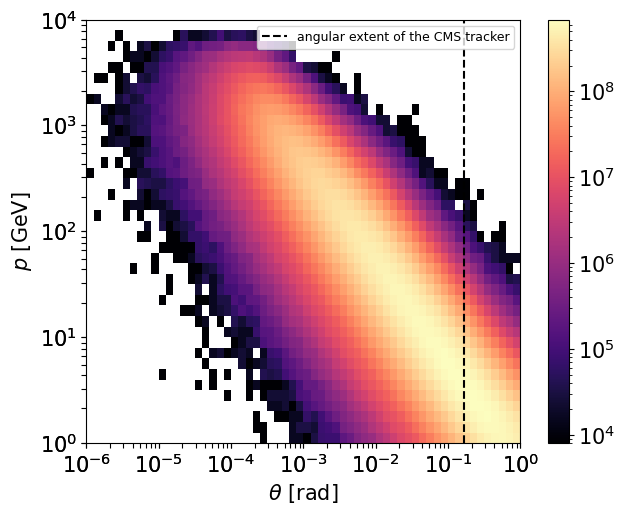

In [10]:
plot = foresee.get_spectrumplot(pid='130', generator='EPOSLHC', energy='13.6', )
theta = 0.1638
plot.axvline(np.log10(theta), color='black', linestyle='--', label='angular extent of the CMS tracker', linewidth=1.5)
plot.legend(loc='upper right', fontsize=9)
plot.gcf().axes[-1].set_label(r"cross section [pb/bin]y")
plot.gcf().axes[0].set_xlabel(r"$\theta$ [rad]")
plot.gcf().axes[0].set_ylabel(r"$p$ [GeV]")
plot.gcf().axes[0].collections[0].set_cmap("magma")
plot.show()


In [ ]:
FB_TO_PB_INV = 1000.0   # 1 fb^-1 = 1000 pb^-1

In [ ]:
fname = foresee.dirpath + "files/hadrons/13.6TeV/EPOSLHC/EPOSLHC_13.6TeV_130.txt"
logth, logp, sigma = np.loadtxt(fname, comments="#", unpack=True)   # sigma = col3, pb/bin

theta = 10.0**logth               # polar angle [rad]  (bin centers, no smearing)
p_array     = 10.0**logp                # momentum [GeV]
pt    = p_array * np.sin(theta)         # transverse momentum [GeV]
pz    = p_array * np.cos(theta)
#eta   = -np.log(np.tan(theta/2))       # pseudorapidity  ( = -ln tan(theta/2) )
eta   = np.arcsinh(pz / pt)       # pseudorapidity  ( = -ln tan(theta/2) )

print("number of bins :", len(sigma))
print("total sigma [pb]:", sigma.sum())

number of bins : 18000
total sigma [pb]: 143889190113.0


In [ ]:
sigma_fwd = sigma 
sigma_all = 2.0 * sigma_fwd

In [ ]:
sigma_fwd_sum = sigma.sum()          # forward hemisphere only (FORESEE convention)
sigma_all_sum = 2.0 * sigma_fwd_sum            # x2 for the backward hemisphere (symmetric CMS)

print(f"sigma(K_L, forward) = {sigma_fwd_sum:.3e} pb")
print(f"sigma(K_L, both)    = {sigma_all_sum:.3e} pb")

sigma(K_L, forward) = 1.439e+11 pb
sigma(K_L, both)    = 2.878e+11 pb


In [ ]:
def n_mesons(sigma_pb, lumi_fb):
    """cross section [pb] -> number of particles in `lumi_fb` fb^-1.
       1 fb^-1 = 1000 pb^-1  <-- factor of 1000."""
    return sigma_pb * lumi_fb * 1000.0

for L in [312, 3000]:                  # Run 3 parking, HL-LHC
    print(f"L={L:>4} fb^-1 :  N(K_L) = {n_mesons(sigma_all_sum, L):.3e}")
N_K_run3 = n_mesons(sigma_all_sum, 312)
N_K_phase2 = n_mesons(sigma_all_sum, 3000)

L= 312 fb^-1 :  N(K_L) = 8.979e+16
L=3000 fb^-1 :  N(K_L) = 8.633e+17


$l_{K_L}(p) = 4.6 \text{km} \frac{p}{150 \text{GeV}}$

# Run 3 Suppresion
Run3: 
N(m) = L × ∫ dp dη  [ dΦ_m/dp dη ]            ← (A) production spectrum (FORESEE) \
                      × Br(m → γγ)              ← (B) branching ratio (PDG) \
                      × f_in-tracker(p)         ← (C) fraction decaying in tracker volume \
			X f_in_eta_range(γ)  	  ← (D) fraction daughter photons are in eta range 0-2.5 \
			X f_VBF  			← (E) fraction passing VBF trigger \
× f_merge(both γ, η)       ← (F) fraction passing merge requirements (includes photon conversions) \


## (B) Branching Ratio 
 Br(KL →γγ) ≃5×10^−4

In [ ]:
B = 5 * 10**-4

## (C): Fraction Decaying in Tracker Volume

In [ ]:
def k_L_decay_length(p):
    return 4.6 * 10**3 * p / 150 # km -> m 
    

In [ ]:
def f_in_tracker_KL(p, eta):
    """Fraction of K_L (momentum p, pseudorapidity eta) that decay inside the tracker.
       Analytic expectation of the signal's MC cut (analyze_configurable_v2.py:146)."""
    L = TRT_length(eta)                  # path length through tracker [m], = 0 outside acceptance
    return 1.0 - np.exp(-L / k_L_decay_length(p))  # ~ L/ell since ell >> L

In [ ]:
print('K long decay length at 150 GeV:', k_L_decay_length(150))

K long decay length at 150 GeV: 4600.0


In [ ]:
print("f at p=150, eta=0 =", f_in_tracker_KL(150, 0)) # ~2e-4, matches ATLAS

f at p=150, eta=0 = 0.00023910184537911938


In [ ]:
f_kl  = f_in_tracker_KL(p_array, eta)          # varies ~1e-3 (low p) to ~1e-5 (high p)

In [ ]:
f_kl

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       4.79659860e-06, 4.27497412e-06, 3.81007558e-06], shape=(18000,))

In [ ]:
sigma_after_intrk = sigma_all * f_kl

In [ ]:
sigma_after_intrk

array([0., 0., 0., ..., 0., 0., 0.], shape=(18000,))

In [ ]:
print("sigma before f_in_trk [pb]:", sigma_all.sum())
print("sigma after  f_in_trk [pb]:", sigma_after_intrk.sum())
print("ratio of f_in_trk:", sigma_after_intrk.sum() / sigma_all.sum())

sigma before f_in_trk [pb]: 287778380226.0
sigma after  f_in_trk [pb]: 6045160831.162817
ratio of f_in_trk: 0.021006306402918076


In [ ]:
suppresion = B * C
print("suppresion factor:", suppresion)
print("cross section before suppresion [pb]:", sigma_all_sum)
print("cross section after suppresion [pb]:", suppresion * sigma_all_sum)

print('number of events before suppresion (312 fb^-1): {:.2e}'.format(n_mesons(sigma_all.sum(), 312)))
print("number of events after suppresion (312 fb^-1): {:.2e}".format(n_mesons(suppresion * sigma_all.sum(), 312)))


suppresion factor: 1.0500000000000001e-05
cross section before suppresion [pb]: 287778380226.0
cross section after suppresion [pb]: 3021672.9923730004
number of events before suppresion (312 fb^-1): 8.98e+16
number of events after suppresion (312 fb^-1): 9.43e+11


In [ ]:
C = 0.021

 **Result: there comes a factor of 0.021 from the requirement of kaon decaying inside the tracker. -> (C) = 0.021**

### (D): Fraction daughter photons are in eta 0-2.5

**Parent kinematics.** $K_L$ has lab momentum $p$, mass $M \equiv M_{K_L}$, moving at polar angle $\theta_{K_L}$ (azimuth fixed to 0, since only $|\eta|$ and $\Delta R$ are used downstream):

$$E=\sqrt{p^2+M^2},\qquad \beta=\frac{p}{E},\qquad \gamma=\frac{E}{M}.$$

**Step 1 - isotropic decay in the rest frame.** Each photon is massless with energy $E^{*}=M/2$. Sample $\cos\theta^{*}\sim\mathcal{U}(-1,1)$, $\phi^{*}\sim\mathcal{U}(0,2\pi)$, and $\sin\theta^{*}=\sqrt{1-\cos^2\theta^{*}}$. Photon 1:

$$\mathbf{p}^{*}_1=E^{*}\left(\sin\theta^{*}\cos\phi^{*},\ \sin\theta^{*}\sin\phi^{*},\ \cos\theta^{*}\right),\qquad \mathbf{p}^{*}_2=-\mathbf{p}^{*}_1 \quad \text{(back-to-back)}.$$

**Step 2 - boost along the parent direction** (into a frame where $K_L$ moves along $+z$):

$$p'_z=\gamma\left(p^{*}_z+\beta E^{*}\right),\qquad p'_x=p^{*}_x,\qquad p'_y=p^{*}_y.$$

(Code: `pz1 = gam*(pzs + beta*Estar)`. Only momentum is tracked - energy isn't needed for $\eta,\phi$.)

**Step 3 - rotate the boost axis onto the true $K_L$ direction** (rotation $R_y(\theta_{K_L})$):

$$p_x^{\text{lab}}=p'_x\cos\theta_{K_L}+p'_z\sin\theta_{K_L},\qquad p_z^{\text{lab}}=-p'_x\sin\theta_{K_L}+p'_z\cos\theta_{K_L},\qquad p_y^{\text{lab}}=p'_y.$$

**Step 4 - read off $(\eta,\phi)$** for each photon:

$$p_T=\sqrt{(p_x^{\text{lab}})^2+(p_y^{\text{lab}})^2},\qquad \eta=\operatorname{arcsinh}\!\left(\frac{p_z^{\text{lab}}}{p_T}\right),\qquad \phi=\operatorname{atan2}\left(p_y^{\text{lab}},\,p_x^{\text{lab}}\right).$$

 The boost $\gamma\sim p/M\gg1$ collimates the two photons around the parent direction, giving a minimum opening angle $\theta_{\min}\approx 2M/p$, i.e. a $\Delta R$ floor $\sim 2M_{K_L}/p$

In [ ]:
from module_VBF import conv_prob_novec, load_conv_prob_table, R_ECAL

M_KL = 0.497611  # GeV
def decay_KL_to_gg(p, theta_KL, rng):
    n=len(p); E=np.sqrt(p**2+M_KL**2); beta=p/E; gam=E/M_KL; Estar=M_KL/2
    cth=rng.uniform(-1,1,n); sth=np.sqrt(1-cth**2); phi=rng.uniform(0,2*np.pi,n)
    px_s,py_s,pz_s = Estar*sth*np.cos(phi), Estar*sth*np.sin(phi), Estar*cth
    def to_lab(pxs,pys,pzs):
        pz1=gam*(pzs+beta*Estar); px1,py1=pxs,pys
        px_l= px1*np.cos(theta_KL)+pz1*np.sin(theta_KL)
        pz_l=-px1*np.sin(theta_KL)+pz1*np.cos(theta_KL)
        pt_l=np.sqrt(px_l**2+py1**2)
        return np.arcsinh(pz_l/pt_l), np.arctan2(py1,px_l)
    e1,f1=to_lab(px_s,py_s,pz_s); e2,f2=to_lab(-px_s,-py_s,-pz_s)
    return e1,f1,e2,f2

In [ ]:
def f_in_eta_range(p, theta_KL, rng, M=500, eta_lo=0.0, eta_hi=2.5):
    """Factor (D): fraction of K_L -> gg decays with BOTH daughter photons
       in |eta| in [eta_lo, eta_hi]. Pure decay kinematics, per (p, theta) bin."""
    w = np.zeros(len(p))
    for _ in range(M):
        e1, f1, e2, f2 = decay_KL_to_gg(p, theta_KL, rng)
        both_in = ((np.abs(e1) >= eta_lo) & (np.abs(e1) <= eta_hi) &
                   (np.abs(e2) >= eta_lo) & (np.abs(e2) <= eta_hi))
        w += both_in.astype(float)
    return w / M

rng = np.random.default_rng(0)
f_eta = f_in_eta_range(p_array, theta, rng)          # per-bin array in [0,1]
sigma_after_eta = sigma_after_intrk * f_eta          # element-wise, per bin
print("factor (D), spectrum-averaged:", sigma_after_eta.sum() / sigma_after_intrk.sum())
print('number of events:', )

factor (D), spectrum-averaged: 0.8165413790300502


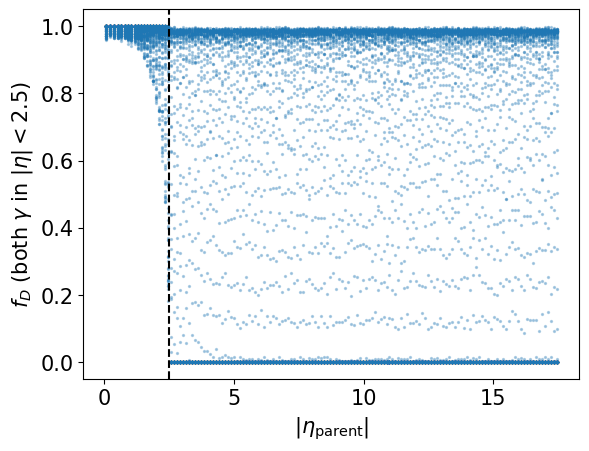

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(np.abs(eta), f_eta, s=2, alpha=0.3)
plt.xlabel(r"$|\eta_{\rm parent}|$"); plt.ylabel(r"$f_D$ (both $\gamma$ in $|\eta|<2.5$)")
plt.axvline(2.5, ls="--", c="k"); plt.show()

- D (this factor): marginal $P(\text{both }\gamma\text{ in }\eta)$ - fine as computed above.
- f_merge (next): must be computed as $P(\text{pass merge + conv}\mid\text{both }\gamma\text{ already in }\eta)$ - i.e. do not re-apply the $\eta$ cut inside the merge MC, or restrict the merge MC to events that already passed $\eta$. Otherwise you'd apply the $\eta$ acceptance twice and undercount.
- f_VBF (E): this one is a whole-event jet quantity, independent of the decay, so it factorizes cleanly as a scalar - no conditioning worry.

In [ ]:
Br_KL_gg = 5.47e-4      # (B) PDG

# per-bin cross section after B, C, D  (sigma_all is the per-bin x2 array; f_kl, f_eta per-bin)
sigma_after_BCD = sigma_all * f_kl * f_eta * Br_KL_gg     # C x D x B, element-wise per bin

print("total sigma after B,C,D [pb]:", sigma_after_BCD.sum())
for L in [312, 3000]:
    print(f"L={L:>4} fb^-1 :  N(K_L, after B,C,D) = {n_mesons(sigma_after_BCD.sum(), L):.3e}")

total sigma after B,C,D [pb]: 2700059.8069602638
L= 312 fb^-1 :  N(K_L, after B,C,D) = 8.424e+11
L=3000 fb^-1 :  N(K_L, after B,C,D) = 8.100e+12
